<a href="https://colab.research.google.com/github/ryang1006/course-buddyfr/blob/main/ACT_2_Implementation_of_Optimization_Strategies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install fiftyone

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from google.colab import drive
from tensorflow.keras.applications.resnet50 import preprocess_input

# all essential libraries into the runtime environment to establish our deep learning and visualization ecosystem.
# TensorFlow provides the core framework, the Keras sub-modules fetch the pretrained ResNet50 architecture
# and functional layer tools, and Matplotlib handles downstream graphing.


from google.colab import drive
drive.mount('/content/drive')

# Mount Google Drive to access your custom dataset

dataset_path = '/content/drive/MyDrive/Vehicle_detection'

if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"CRITICAL ERROR: Cannot find '{dataset_path}'. Please check your Drive folders and update the path.")
else:
    print(f"SUCCESS: Drive mounted and dataset path located!")

# This fucntion sets up your directory pathway variable and implements an automated sanity check using Python's filesystem module.
# It acts as a defensive programming shield, halting code execution immediately
# if your Drive path contains a typo rather than throwing a cryptic error deep inside TensorFlow later.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
SUCCESS: Drive mounted and dataset path located!


In [ ]:
batch_size = 32
img_height = 224
img_width = 224

# This group declares the core hyperparameters that dictate how individual data images are shaped and grouped.
# It sets a uniform spatial resolution of $224 \times 224$ pixels to match ResNet50's default dimensions
# and creates processing batches of 32 samples to optimize GPU memory efficiency.

# 1. Load the raw datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
  dataset_path,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size
)

# This function initializes your training dataset pipeline by scanning your Drive directory and extracting images assigned to the training split.
# It automatically infers class directories, scales the dimensions on the fly,
# and uses a static seed to ensure your data shuffling remains perfectly reproducible.

val_ds = tf.keras.utils.image_dataset_from_directory(
  dataset_path,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size
)

# This mirrored function sets up the separate validation pipeline by drawing from the remaining 20% holdout split of your cloud directory.
# It uses the exact same seed and shape parameters as the training pipeline to guarantee there is zero data leakage or dimensional mismatch between splits.

# 2. THE DEBUG CHECK: Capture the exact number of classes dynamically
class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Debug Check - Classes found: {num_classes} ({class_names})")

# This tracking logic dynamically extracts the unique class labels found by the directory reader and stores their total integer count.
# Printing this information acts as a crucial check against the "None Shape Error,"
# verifying that your network's output layer will exactly match your data categories.

for images, labels in train_ds.take(1):
    print(f"Debug Check - Image batch shape: {images.shape}")
    print(f"Debug Check - Label batch shape: {labels.shape}")
# This loop pulls a single tensor batch directly from your stream to display its exact matrix structural properties.
# It serves as a visual checkpoint to verify that batch sizing and multi-channel configurations are perfectly formatted before the tensors ever touch neural weights.

# 3. Apply the mandatory ResNet50 preprocessing
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)

# This line maps ResNet50’s native mathematical scaling across your dataset using background CPU threads to prevent processing bottlenecks.
# It normalizes raw pixel values into zero-centered distributions,
# which completely eliminates the severe gradient inflation that triggers standard NaN loss explosions.

Found 477 files belonging to 3 classes.
Using 382 files for training.
Found 477 files belonging to 3 classes.
Using 95 files for validation.
Debug Check - Classes found: 3 (['test', 'train', 'valid'])
Debug Check - Image batch shape: (32, 224, 224, 3)
Debug Check - Label batch shape: (32,)


In [ ]:
# 1. Load the base ResNet50 model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
# This instantiates the core ResNet50 backbone loaded with ImageNet weights that are already highly proficient at detecting generalized visual features.
# Setting include_top=False strips away the original thousand-class classification layer so we can attach a tailored classifier head.

# 2. Freeze the base to protect pre-trained weights
base_model.trainable = False
# This globally locks the entire parameter matrix of the downloaded ResNet backbone to render it completely immune to backpropagation updates.
# It establishes a static feature extraction layer that preserves complex pretrained knowledge and keeps our initial training focused purely on our new layers.


# 3. Build the custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
# This applies a spatial pooling operation that collapses the base model's final multi-dimensional convolutional feature maps into a flattened vector.
# It drastically cuts down the overall parameter footprint of the model, which serves as an important defense against early overfitting.

predictions = Dense(num_classes, activation='softmax')(x) # Uses dynamic class count
# This appends a dense fully-connected layer configured with a softmax activation to output clean probability distributions across your dynamic class count.
# The final Model initialization binds these components together into a single,
# cohesive functional graph from input to output.


model = Model(inputs=base_model.input, outputs=predictions)

# 4. Compile with standard Adam
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
# This compiles the model using the standard Adam optimizer at a fixed baseline learning rate alongside an integer-compatible crossentropy objective function.
# It sets up the mathematical tracking rules that calculate training mistakes and updates the unfrozen weights accordingly.

model.summary()
# Gives a summary of the model, which provides the following information about the model
# Name and type of all layers in the model; Output shape for each layer; Number of weight parameters of each layer;
# If the model has general topology (discussed below), the inputs each layer receives
# The total number of trainable and non-trainable parameters of the model.

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,593,859 (90.00 MB)

 Trainable params: 6,147 (24.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# We specify our baseline optimization time footprint by locking our training iteration limit parameter.
# Assigning an explicit value of ten ensures our network passes over the dataset enough times to reach a clear plateau.
epochs_baseline = 10

# We execute our standard parameter adjustments by invoking the native fit function on our baseline model architecture.
# This streams our normalized imagery batches alongside our validation checks to map our baseline performance metrics into a single storage object.
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs_baseline
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.7565 - loss: 1.0308 - val_accuracy: 0.8737 - val_loss: 1.0605
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 215ms/step - accuracy: 0.8665 - loss: 0.7403 - val_accuracy: 0.8105 - val_loss: 0.6669
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 225ms/step - accuracy: 0.8743 - loss: 0.4912 - val_accuracy: 0.8737 - val_loss: 0.5864
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 372ms/step - accuracy: 0.8743 - loss: 0.4435 - val_accuracy: 0.8737 - val_loss: 0.5548
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 221ms/step - accuracy: 0.8796 - loss: 0.4054 - val_accuracy: 0.8737 - val_loss: 0.5395
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 234ms/step - accuracy: 0.8796 - loss: 0.3754 - val_accuracy: 0.8737 - val_loss: 0.5468
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 229ms/step - accuracy: 0.8796 - loss: 0.3512 - val_accuracy: 0.8737 - val_loss: 0.5461
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 348ms/step - accuracy: 0.8822 - loss: 0.3331 - val_accuracy: 0.87

In [ ]:
# We globally unfreeze our base model parameters to make its underlying pre-trained convolutional filters susceptible to weight adjustments.
# Activating this parameter changes the layers from a static descriptor into an adaptable pattern matcher that can fit new features.
base_model.trainable = True

# We construct a step iteration loop that automatically sweeps through the network layers and re-freezes all nodes except the top fifteen.
# This precision unfreezing setup restricts structural modifications exclusively to high-level abstract classification filters while early edges remain locked.
for layer in base_model.layers[:-15]:
    layer.trainable = False

# We implement a normalization variance shield by writing a validation loop that intercepts every batch normalization component.
# Forcing these specific layers to remain locked prevents our miniature data tracking batch sizes from distorting our pre-trained running weights.
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# We create two separate cosine decay learning rate schedulers to apply differential learning rates to our model.
# The backbone gets a very small starting rate to protect the pre-trained weights while our new head gets a larger starting rate to learn quickly.
lr_schedule_backbone = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-5,
    decay_steps=1000
)

lr_schedule_head = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=1000
)

# We instantiate two distinct Adam optimizers using the schedules we just created.
# This allows us to actually apply the differential speeds during the training process.
optimizer_backbone = Adam(learning_rate=lr_schedule_backbone)
optimizer_head = Adam(learning_rate=lr_schedule_head)

# We code a custom class container that inherits from the core Keras functional framework infrastructure.
# This configuration gives us manual control over backpropagation steps without losing standard tracking features.
class DifferentialModel(Model):
    # We define our local instantiation scheme to accept our base core and head layers as distinct object collections.
    # Storing these blocks separately allows us to fetch their respective weights independently down the line.
    def __init__(self, base_model, head_layers):
        super().__init__()
        self.base_model = base_model
        self.head_layers = head_layers

    # We structure our definitive forward pass calculation routine to prescribe exactly how tensors transition through our layers.
    # This method guides our input feature distributions directly from raw data maps to final decision probabilities.
    def call(self, inputs):
        x = self.base_model(inputs)
        for layer in self.head_layers:
            x = layer(x)
        return x

    # We completely override the default training sequence method to manually handle gradient propagation math.
    # Unpacking our incoming dataset batch separates our image attributes from their true category targets.
    def train_step(self, data):
        x, y = data
        # We establish a TensorFlow Gradient Tape context to record every single tensor operation that occurs during the forward pass.
        # Measuring current predictions against true targets under this tape yields a clear crossentropy error score.
        with tf.GradientTape() as tape:
            y_pred = self(x, training=True)
            loss = self.compute_loss(y=y, y_pred=y_pred)

        # We extract the separate trainable properties of the backbone and gather head variables into independent list arrays.
        # Grouping these weights into distinct entities is necessary so we can update them at custom step speeds.
        backbone_vars = [v for v in self.base_model.trainable_variables]
        head_vars = []
        for layer in self.head_layers:
            head_vars.extend(layer.trainable_variables)

        # We ask our gradient recording tape to calculate separate mathematical derivatives for both sets of network weights.
        # Slicing the completed output list provides isolated directional adjustments for each structural section of our graph.
        grads = tape.gradient(loss, backbone_vars + head_vars)
        grads_backbone = grads[:len(backbone_vars)]
        grads_head = grads[len(backbone_vars):]

        # We invoke our safe backbone optimizer to step through our base weights at a highly conservative speed.
        # Right after we apply our aggressive head optimizer to let our fresh layers adapt quickly without ruining ImageNet details.
        if backbone_vars:
            optimizer_backbone.apply_gradients(zip(grads_backbone, backbone_vars))
        if head_vars:
            optimizer_head.apply_gradients(zip(grads_head, head_vars))

        # We loop through our global monitoring metrics to keep our progress meters completely accurate after every operational step.
        # Sorting evaluations into loss or accuracy boxes ensures our final summary containers remain fully populated.
        for metric in self.metrics:
            if metric.name == "loss":
                metric.update_state(loss)
            else:
                metric.update_state(y, y_pred)
        return {m.name: m.result() for m in self.metrics}

# We slice our intermediate network configurations out of our previous architecture and map them into an explicit list.
# Passing these objects to our custom class container prepares our multi speed optimization setup for action.
head_layers = [model.layers[-2], model.layers[-1]]
diff_model = DifferentialModel(base_model, head_layers)

# We call our compilation routine to declare our target crossentropy losses and structural metric parameters.
# This re compilation step is required by Keras to properly map our manual training properties into the virtual memory workspace.
diff_model.compile(
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# We configure our fine tuning run duration parameters and initialize the advanced optimization execution loop.
# Saving these evaluation points into a separate history fine object keeps our custom tuning scores separate from our baseline data.
epochs_fine = 10
history_fine = diff_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs_fine
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.8901 - loss: 0.3396 - val_accuracy: 0.8737 - val_loss: 0.5931
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 212ms/step - accuracy: 0.9084 - loss: 0.2556 - val_accuracy: 0.8737 - val_loss: 0.5497
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 284ms/step - accuracy: 0.9267 - loss: 0.1985 - val_accuracy: 0.8632 - val_loss: 0.5713
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 222ms/step - accuracy: 0.9476 - loss: 0.1657 - val_accuracy: 0.8737 - val_loss: 0.5693
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 221ms/step - accuracy: 0.9712 - loss: 0.1236 - val_accuracy: 0.8632 - val_loss: 0.5875
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 229ms/step - accuracy: 0.9686 - loss: 0.1011 - val_accuracy: 0.8526 - val_loss: 0.6164
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 321ms/step - accuracy: 0.9895 - loss: 0.0764 - val_accuracy: 0.8737 - val_loss: 0.6355
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 233ms/step - accuracy: 0.9895 - loss: 0.0614 - val_accuracy: 0.87

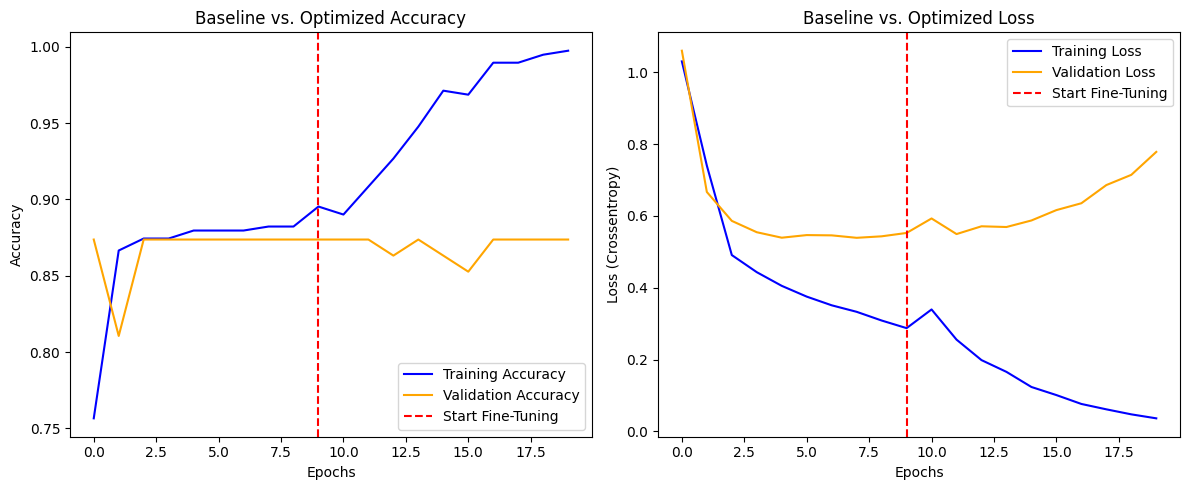

In [ ]:
# We concatenate our chronological data metrics from both separate runs to construct continuous timelines.
# Merging these lists yields single continuous coordinate paths tracking accuracy metrics across twenty complete epochs.
acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

# We execute the exact same list composition math to assemble our continuous loss tracking timelines.
# Combining these historical values ensures our validation curves can be mapped across our entire optimization experiment.
loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

# We build a generic canvas layout and allocate target slot matrices using standard multi plot subplot commands.
# This step maps out an accuracy chart configuration on the left side while creating a mirrored slot configuration for loss.
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)

# We plot our chronological accuracy performance results as continuous blue and orange visual chart strokes.
# Drawing an explicit vertical red boundary line marks the precise historical checkpoint where our fine tuning phase was activated.
plt.plot(acc, label='Training Accuracy', color='blue')
plt.plot(val_acc, label='Validation Accuracy', color='orange')
plt.axvline(x=epochs_baseline-1, color='red', linestyle='--', label='Start Fine-Tuning')

# We apply clear axis labels and legends to map out coordinates for an external reviewer.
# Setting localized layout text properly annotates our boundaries so the chart can be decoded effortlessly.
plt.legend(loc='lower right')
plt.title('Baseline vs. Optimized Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# We switch focus onto our second column canvas coordinate slot to begin constructing our error chart.
# Drawing continuous data arrays for training and validation metrics maps out our baseline error paths alongside advanced trends.
plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='orange')

# We drop a mirrored vertical boundary marker line across our error chart layout to separate our training phases visually.
# Annotating the coordinates with clear headings and scales clarifies exactly how our dynamic multi speed optimizers reduced errors.
plt.axvline(x=epochs_baseline-1, color='red', linestyle='--', label='Start Fine-Tuning')
plt.legend(loc='upper right')
plt.title('Baseline vs. Optimized Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (Crossentropy)')

# We invoke automated spacing configurations to clean up overlapping text boundaries across our subplots.
# The final flushing function pushes the completed data visualization out of memory and renders the graphics in our console.
plt.tight_layout()
plt.show()